In [ ]:
#Names: Trevor Henderson, Alex Velasquez
#dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices

# Import necessary libraries for data manipulation, math, and plotting

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [30]:
# Load the dataset and remove any rows with missing values
df = pd.read_csv('housing.csv')
df = df.dropna()

# Print the first 20 rows to inspect the data
print(df.head(20))

    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0     -122.23     37.88                41.0        880.0           129.0   
1     -122.22     37.86                21.0       7099.0          1106.0   
2     -122.24     37.85                52.0       1467.0           190.0   
3     -122.25     37.85                52.0       1274.0           235.0   
4     -122.25     37.85                52.0       1627.0           280.0   
5     -122.25     37.85                52.0        919.0           213.0   
6     -122.25     37.84                52.0       2535.0           489.0   
7     -122.25     37.84                52.0       3104.0           687.0   
8     -122.26     37.84                42.0       2555.0           665.0   
9     -122.25     37.84                52.0       3549.0           707.0   
10    -122.26     37.85                52.0       2202.0           434.0   
11    -122.26     37.85                52.0       3503.0           752.0   
12    -122.2

In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Convert ocean_proximity from text (NEAR BAY, INLAND, etc.) to numbers
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

print(df.head(10))

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   
7    -122.25     37.84                52.0       3104.0           687.0   
8    -122.26     37.84                42.0       2555.0           665.0   
9    -122.25     37.84                52.0       3549.0           707.0   

   population  households  median_income  median_house_value  ocean_proximity  
0       322.0       126.0         8.3252            452600.0                3  
1      2401.0 

In [32]:
# Average number of rooms per household
df['rooms_per_household'] = df['total_rooms'] / df['households']

# percentage of bedrooms to total rooms
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

# number of people per house
df['population_per_household'] = df['population'] / df['households']

# Print to verify the new columns were created correctly
print(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head(10))

   rooms_per_household  bedrooms_per_room  population_per_household
0             6.984127           0.146591                  2.555556
1             6.238137           0.155797                  2.109842
2             8.288136           0.129516                  2.802260
3             5.817352           0.184458                  2.547945
4             6.281853           0.172096                  2.181467
5             4.761658           0.231774                  2.139896
6             4.931907           0.192899                  2.128405
7             4.797527           0.221327                  1.788253
8             4.294118           0.260274                  2.026891
9             4.970588           0.199211                  2.172269


In [33]:
# select our prediction inputs
X = df[['housing_median_age', 'median_income', 'ocean_proximity',
        'rooms_per_household', 'bedrooms_per_room', 'population_per_household']]

# Select variable we want to predict
y = df['median_house_value']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (20433, 6)
y shape: (20433,)


In [34]:
from sklearn.model_selection import train_test_split

# Split data into testing and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Testing samples: ', X_test.shape[0])

Training samples: 16346
Testing samples:  4087


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Transform features into polynomial features of degree 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train the model on the polynomial features
model = LinearRegression()
model.fit(X_train_poly, y_train)

print('Model trained with', X_train_poly.shape[1], 'polynomial features')

Model trained with 28 polynomial features


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate predictions using the polynomial transformed test data
y_pred = model.predict(X_test_poly)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f'MAE:   ${mae:,.2f}')
print(f'MSE:   {mse:,.2f}')
print(f'R²:    {r2:.4f}')

MAE:   $51,130.06
MSE:   5,305,707,436.37
R²:    0.6120


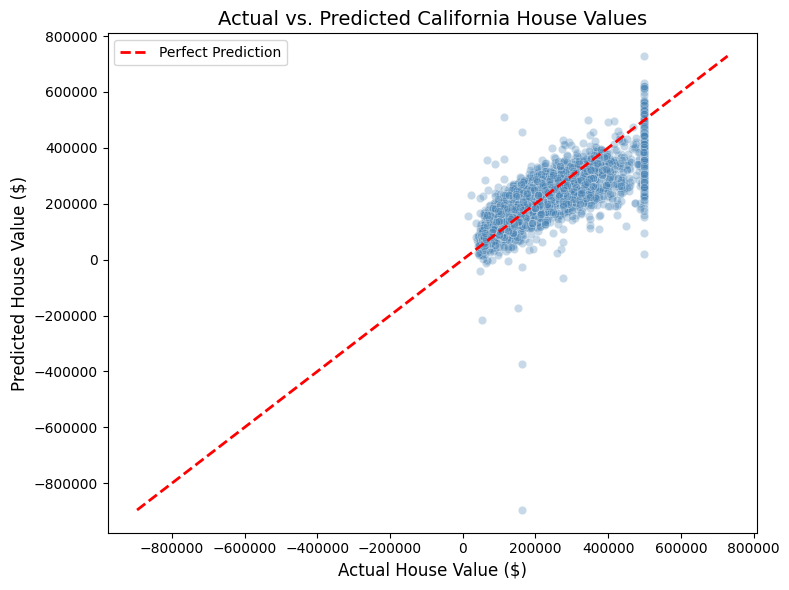


R2 = 0.6120 means the model explains 61.2% of the variance in house values.


In [37]:
# Scatter plot of actual vs predicted house values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', linewidths=0.5)

# Red dashed line represents where perfect predictions would fall
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual House Value ($)', fontsize=12)
plt.ylabel('Predicted House Value ($)', fontsize=12)
plt.title('Actual vs. Predicted California House Values', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nR2 = {r2:.4f} means the model explains {r2*100:.1f}% of the variance in house values.')

In [ ]:
# A linear regression model such as this one would be able to help real estate companies
# predict values of potential investments based on similar features. Although this model is only 60% accurate,
# this would help them get a ballpark number that they can use as a reference. This would help them be able to find
# undervalued homes, create listing prices, and better give offers on homes they want to buy. The r^2 of this model
# means that the model was able to predict the correct value about 60% of the time.